In [1]:
"""
Notebook 3 — Criticality Scoring + Structural Visualisation

Stages:
1. Load transform metrics
2. Normalise supply-side metrics
3. Normalise demand-side metrics
4. Composite criticality score + ranking
5. Export criticality table
6. Load country structural metrics (Notebook 2)
7. Structural plots + hidden link detection
8. Export Notebook 3 outputs
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.utility import (
    load_parquet, save_parquet
)

In [2]:
# %%
# 1. Load transform metrics
transform = load_parquet("notepad_02_transform_metrics.parquet")
transform = transform.set_index("Mineral Code")

# %%
# 2. Normalisation helper
def minmax(series):
    return (series - series.min()) / (series.max() - series.min())

# %%
# 3. Normalise supply‑side metrics
transform["HHI_norm"] = minmax(transform["HHI"])
transform["ProducerDiversity_norm"] = minmax(transform["Producer Diversity"])

# Supply Risk = weighted combination
# Higher HHI → higher risk
# Lower diversity → higher risk
transform["SupplyRisk"] = (
    0.7 * transform["HHI_norm"] +
    0.3 * (1 - transform["ProducerDiversity_norm"])
)

# %%
# 4. Normalise demand‑side metrics
transform["SectorUsage_norm"] = minmax(transform["Sector Usage Count"])
transform["EconomicImportance_norm"] = minmax(transform["Economic Importance"])

# Economic Importance Score
transform["DemandImportance"] = (
    0.4 * transform["SectorUsage_norm"] +
    0.6 * transform["EconomicImportance_norm"]
)

# %%
# 5. Composite Criticality Score
transform["CriticalityScore"] = (
    0.5 * transform["SupplyRisk"] +
    0.5 * transform["DemandImportance"]
)

# %%
# 6. Ranking
transform["Rank"] = transform["CriticalityScore"].rank(ascending=False).astype(int)

# %%
# 7. Save final scoring table
save_parquet(transform.reset_index(), "notepad_03_criticality_scores.parquet")


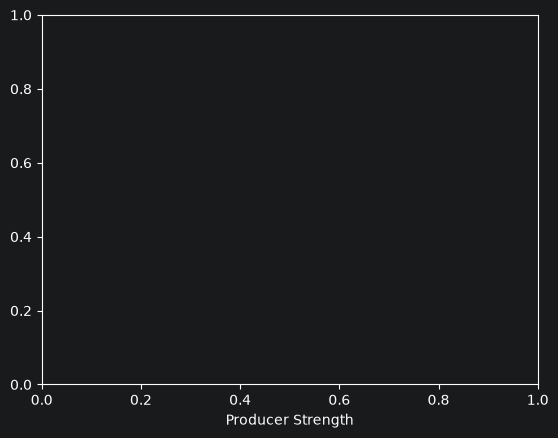

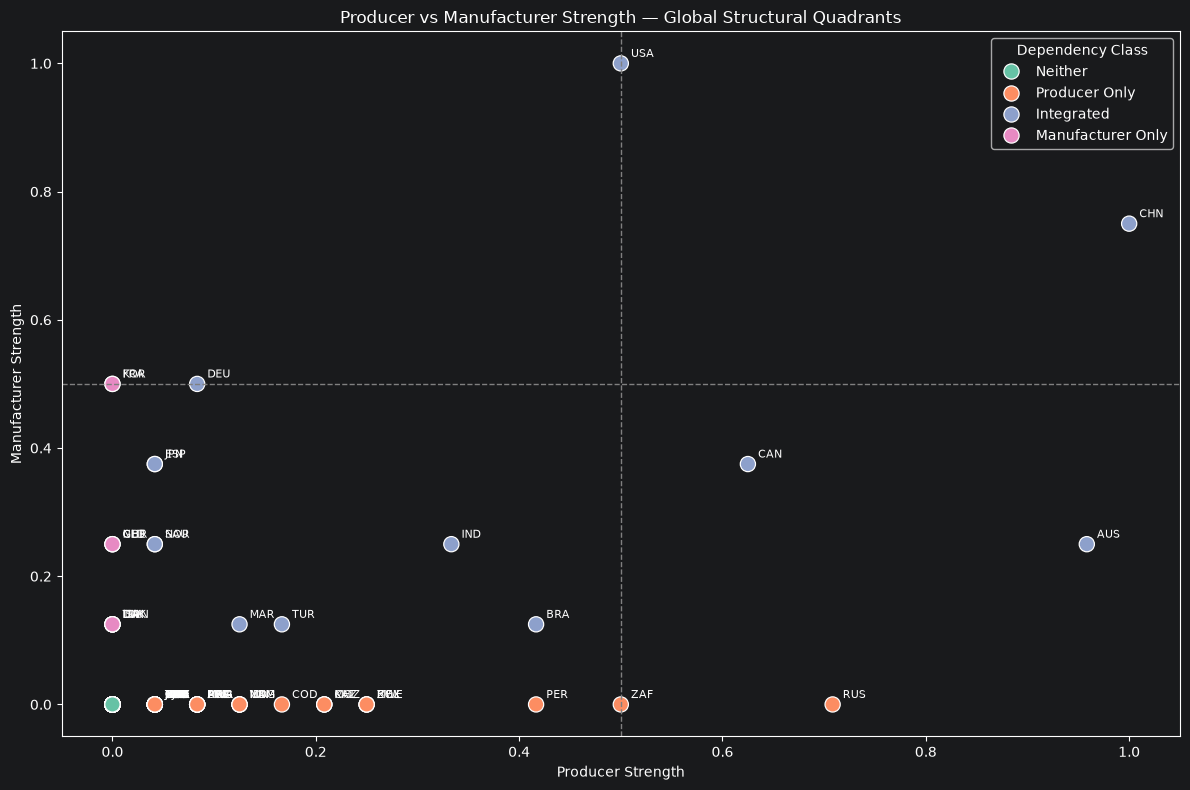

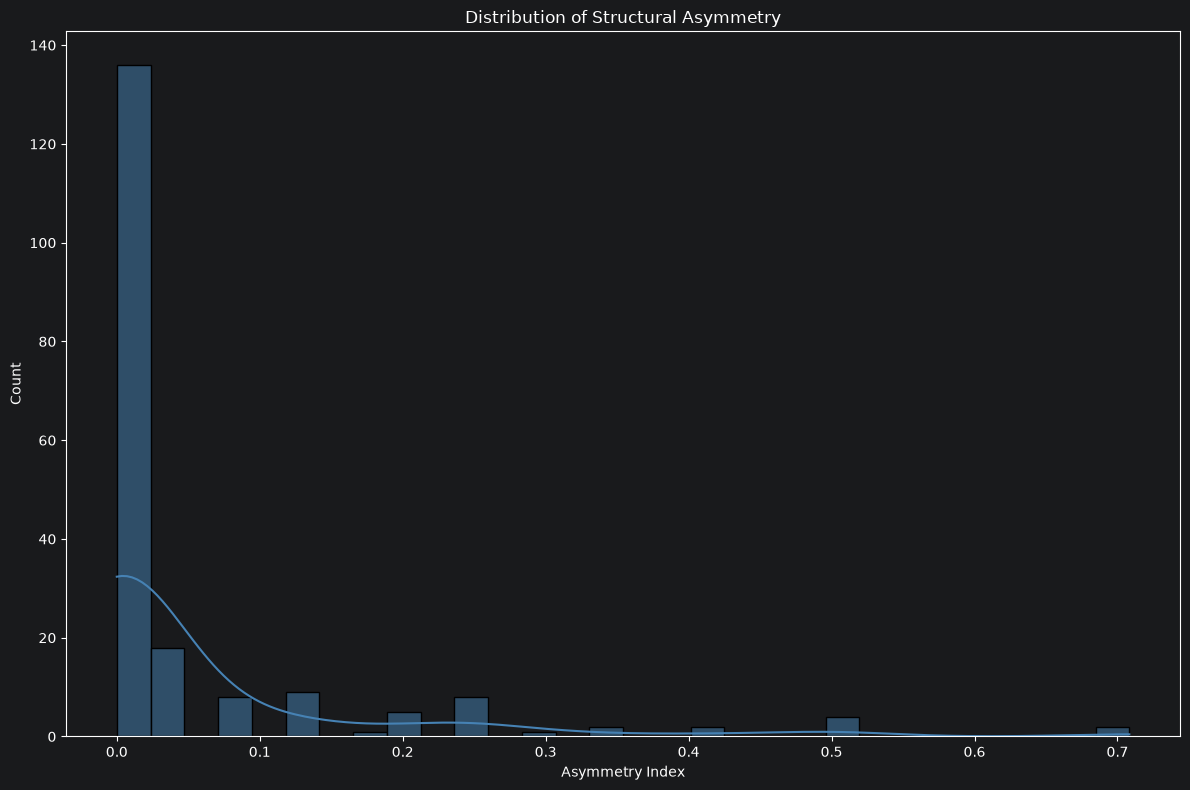

Notebook 3 complete.


In [3]:
# LOAD NOTEBOOK 2 OUTPUT
links = load_parquet("country_links.parquet")


links["Producer Count"] = links["Producer Count"].fillna(0)
links["Manufacturer Count"] = links["Manufacturer Count"].fillna(0)
plt.xlabel("Producer Strength")

# -------------------------------------------------
# 8. STRUCTURAL PLOTS
# -------------------------------------------------

# --- Quadrant Chart ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=links,
    x="Producer Strength",
    y="Manufacturer Strength",
    hue="Dependency Class",
    palette="Set2",
    s=120
)

label_subset = links[(links["Producer Count"] > 0) | (links["Manufacturer Count"] > 0)]
for _, row in label_subset.iterrows():
    plt.text(
        row["Producer Strength"] + 0.01,
        row["Manufacturer Strength"] + 0.01,
        row["Country Code"],
        fontsize=8
    )

plt.axhline(0.5, color="grey", linestyle="--", linewidth=1)
plt.axvline(0.5, color="grey", linestyle="--", linewidth=1)
plt.title("Producer vs Manufacturer Strength — Global Structural Quadrants")
plt.xlabel("Producer Strength")
plt.ylabel("Manufacturer Strength")
plt.tight_layout()
plt.show()

# --- Asymmetry Map ---
plt.figure(figsize=(12, 8))
sns.histplot(
    links["Asymmetry Index"],
    bins=30,
    kde=True,
    color="steelblue"
)
plt.title("Distribution of Structural Asymmetry")
plt.xlabel("Asymmetry Index")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 9. CAPABILITY RANKING
# -------------------------------------------------
cap_rank = (
    links[["Country", "Country Code", "Capability Score"]]
    .sort_values("Capability Score", ascending=False)
    .reset_index(drop=True)
)

# -------------------------------------------------
# 10. HIDDEN LINK DETECTION
# -------------------------------------------------
links["Hidden Link Score"] = links["Producer Strength"] * (1 - links["Manufacturer Strength"])

hidden_links = (
    links[[
        "Country", "Country Code",
        "Producer Count", "Manufacturer Count",
        "Producer Strength", "Manufacturer Strength",
        "Hidden Link Score"
    ]]
    .sort_values("Hidden Link Score", ascending=False)
)

# -------------------------------------------------
# 11. DEPENDENCY GRAPH (Adjacency Matrix)
# -------------------------------------------------
producers = links[links["Producer Count"] > 0]["Country Code"].tolist()
manufacturers = links[links["Manufacturer Count"] > 0]["Country Code"].tolist()

dependency_matrix = pd.DataFrame(
    0.0,
    index=producers,
    columns=manufacturers
)

for p in producers:
    p_strength = links.loc[links["Country Code"] == p, "Producer Strength"].values[0]
    for m in manufacturers:
        m_strength = links.loc[links["Country Code"] == m, "Manufacturer Strength"].values[0]
        dependency_matrix.loc[p, m] = p_strength * m_strength

# -------------------------------------------------
# 12. EXPORT NOTEBOOK 3 OUTPUTS
# -------------------------------------------------
save_parquet(dependency_matrix, "dependency_matrix.parquet")
save_parquet(cap_rank, "capability_ranking.parquet")
save_parquet(hidden_links, "hidden_links.parquet")

print("Notebook 3 complete.")


In [13]:
country_master = load_parquet("country_links.parquet")
country_master["GDP_per_capita"] = country_master["GDP_IMF_2026"] / country_master["Population"]
country_master["Land_per_capita"] = country_master["Land_Area_km2"] / country_master["Population"]
country_master["GNI_per_capita"] = country_master["GNI_Coefficient"]  # already per capita-like
# country_master["Capability_per_GDP"] = country_master["Capability Score"] / country_master["GDP_IMF_2026"]


<Axes: xlabel='Dependency Class', ylabel='GDP_IMF_2026'>

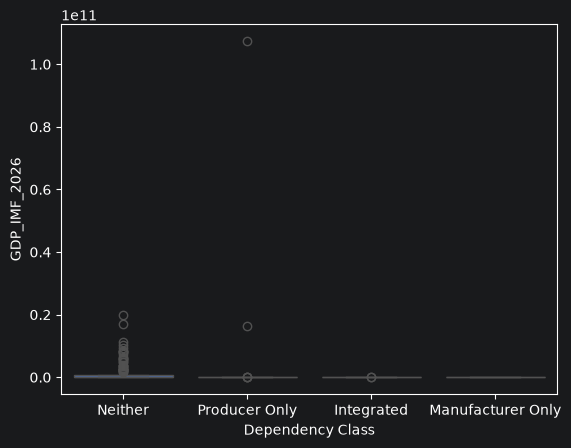

In [17]:
sns.boxplot(data=country_master, x="Dependency Class", y="GDP_IMF_2026")


<Axes: xlabel='Dependency Class', ylabel='Population'>

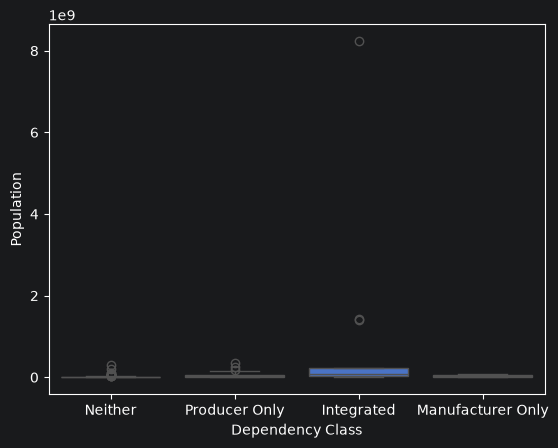

In [16]:
sns.boxplot(data=country_master, x="Dependency Class", y="Population")


<Axes: xlabel='Dependency Class', ylabel='Land_Area_km2'>

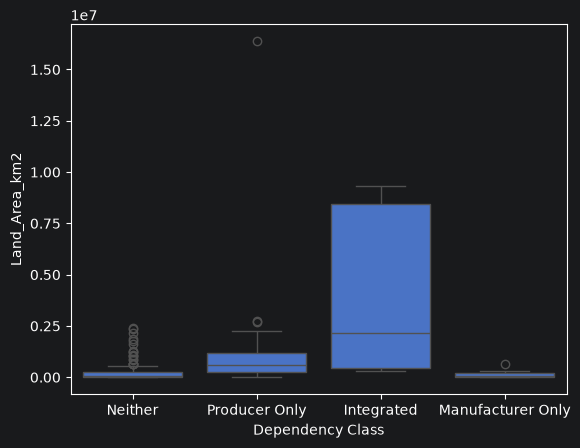

In [18]:
sns.boxplot(data=country_master, x="Dependency Class", y="Land_Area_km2")

<Axes: xlabel='Dependency Class', ylabel='GNI_Coefficient'>

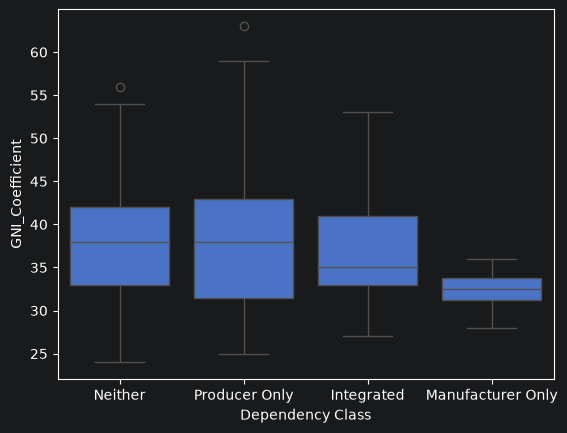

In [19]:
sns.boxplot(data=country_master, x="Dependency Class", y="GNI_Coefficient")

<Axes: xlabel='Population', ylabel='GDP_IMF_2026'>

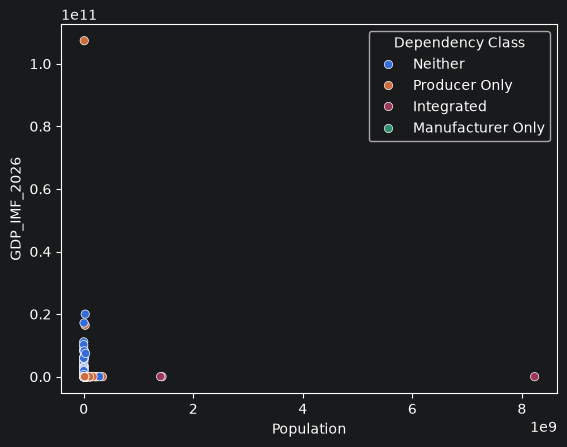

In [20]:
sns.scatterplot(
    data=country_master,
    x="Population",
    y="GDP_IMF_2026",
    hue="Dependency Class"
)


<Axes: xlabel='Land_Area_km2', ylabel='GDP_IMF_2026'>

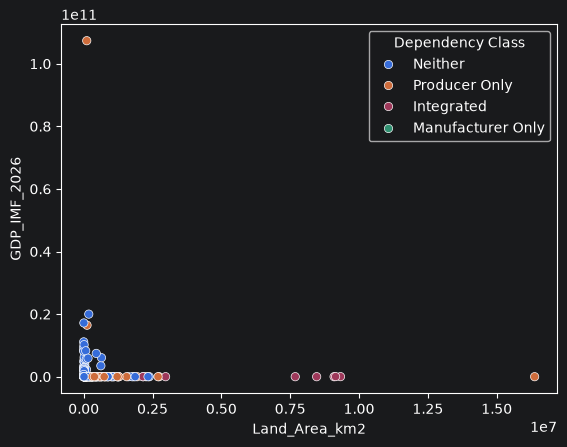

In [21]:
sns.scatterplot(
    data=country_master,
    x="Land_Area_km2",
    y="GDP_IMF_2026",
    hue="Dependency Class"
)


<Axes: xlabel='GNI_Coefficient', ylabel='GDP_IMF_2026'>

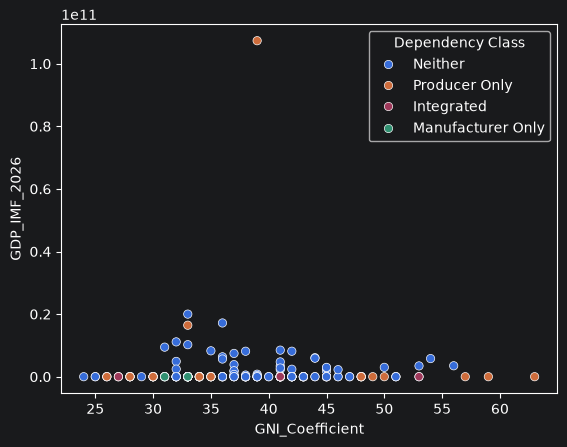

In [22]:
sns.scatterplot(
    data=country_master,
    x="GNI_Coefficient",
    y="GDP_IMF_2026",
    hue="Dependency Class"
)


<Axes: >

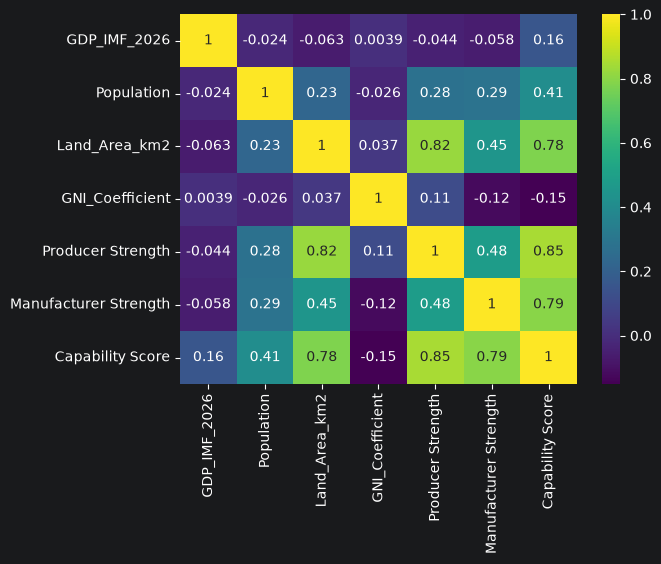

In [23]:
corr = country_master[[
    "GDP_IMF_2026",
    "Population",
    "Land_Area_km2",
    "GNI_Coefficient",
    "Producer Strength",
    "Manufacturer Strength",
    "Capability Score"
]].corr()

sns.heatmap(corr, annot=True, cmap="viridis")


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = country_master[["GDP_IMF_2026", "Population", "Land_Area_km2", "GNI_Coefficient"]]
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42).fit(X_scaled)
country_master["Cluster"] = kmeans.labels_


KMeans(n_clusters=4, random_state=42)
